In [1]:
# importing libs

import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# uploading files

from google.colab import files

uploaded = files.upload()

csv_name = list(uploaded.keys())[0]
df = pd.read_csv(csv_name)

df.head()

Saving foo2023_lmc_ph7_full.csv to foo2023_lmc_ph7_full.csv


,table_name,foo2023_lmc_ph7_dataset,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,pressure_bar,Jw_LMH,Jw_um_s,pH,R_Li,R_Mg
2,6,28.98,8.05,6.94,-0.207,0.521
3,8,42.18,11.72,6.71,-0.184,0.6
4,10,54.17,15.05,6.83,-0.142,0.599


In [7]:
# extracting the 4 experimental rows

csv_name = "foo2023_lmc_ph7_full.csv"

raw = pd.read_csv(csv_name, header=None, dtype=str)
hdr = raw.index[raw[0] == "pressure_bar"][0]
data = raw.iloc[hdr + 1:].copy()
data.columns = raw.iloc[hdr].tolist()

data = data[pd.to_numeric(data["pressure_bar"], errors="coerce").notna()]
data = data.apply(pd.to_numeric).reset_index(drop=True)

data

,pressure_bar,Jw_LMH,Jw_um_s,pH,R_Li,R_Mg
0,6,28.98,8.05,6.94,-0.207,0.521
1,8,42.18,11.72,6.71,-0.184,0.600
2,10,54.17,15.05,6.83,-0.142,0.599
3,12,67.18,18.66,6.92,-0.125,0.653


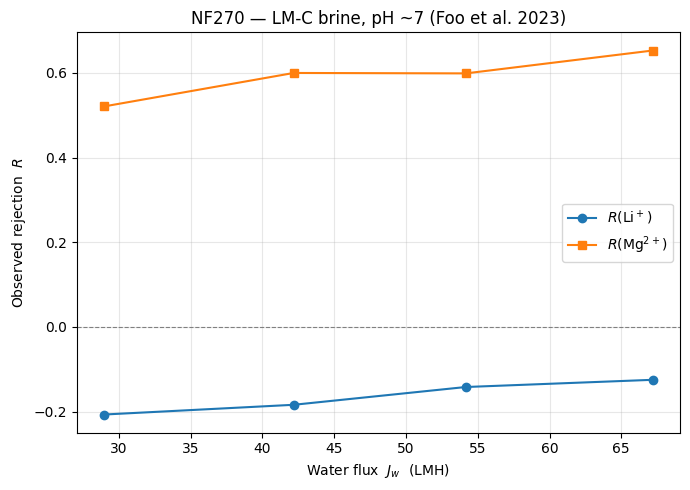

In [8]:
# plotting R_Li and R_Mg vs Jw_LMH

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(data["Jw_LMH"], data["R_Li"], "o-", label=r"$R(\mathrm{Li}^+)$")
ax.plot(data["Jw_LMH"], data["R_Mg"], "s-", label=r"$R(\mathrm{Mg}^{2+})$")

ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel(r"Water flux  $J_w$  (LMH)")
ax.set_ylabel(r"Observed rejection  $R$")
ax.set_title("NF270 — LM-C brine, pH ~7 (Foo et al. 2023)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()